# Credit Card Customer Default Analysis

This notebook explores customer balances, payment behavior, and repayment status. It compares a linear probability regression with logistic regression and generates default probabilities for the test customers.

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from scipy.stats.qmc import LatinHypercube
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss, log_loss, mean_absolute_error, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 1. Load the datasets

Update `DATA_DIR` if the CSV files are stored elsewhere.

In [26]:
DATA_DIR = Path.cwd() / 'inter-uni-datathon-stream-1-credit-card-clients'
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'Missing training values: {train.isna().sum().sum()}')
print(f'Default rate: {train.default.mean():.2%}')
train.head()

Train shape: (24000, 25)
Test shape:  (6000, 24)
Missing training values: 0
Default rate: 22.12%


,client_id,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,CC_0000F52C3717,50000,2,1,2,26,1,2,0,0,...,39475,40187,40992,2200,1962,1562,1500,1474,2300,0
1,CC_0008C4E44BB9,150000,2,1,2,26,-1,-1,-1,0,...,18400,1527,1527,0,18600,0,1527,0,0,0
2,CC_000B4B1BEDF6,450000,2,2,1,38,-2,-2,-2,-2,...,17255,17515,0,15008,1200,5255,4566,0,3648,0
3,CC_000D492CE7AD,230000,2,2,2,30,0,0,0,0,...,108826,100862,92481,6000,6000,4000,4000,3500,4000,0
4,CC_000DCFA992C4,160000,2,2,2,34,-1,-1,-1,-1,...,13780,12297,12752,24000,8000,13780,12300,12752,6000,0


## 2. Engineer interpretable customer metrics

The engineered fields describe average balances, total payments, payment-to-balance behavior, credit utilization, and delinquency history. A correlation matrix then shows how the continuous features move together.

In [27]:
def add_customer_metrics(data):
    result = data.copy()
    bill_columns = [f'BILL_AMT{month}' for month in range(1, 7)]
    payment_columns = [f'PAY_AMT{month}' for month in range(1, 7)]
    status_columns = ['PAY_0'] + [f'PAY_{month}' for month in range(2, 7)]
    result['average_bill_balance'] = result[bill_columns].mean(axis=1)
    result['average_payment'] = result[payment_columns].mean(axis=1)
    result['total_bill_balance'] = result[bill_columns].sum(axis=1)
    result['total_payment'] = result[payment_columns].sum(axis=1)
    result['payment_to_bill_ratio'] = result['total_payment'] / (result['total_bill_balance'].abs() + 1)
    result['credit_utilization'] = result['average_bill_balance'] / (result['LIMIT_BAL'] + 1)
    result['maximum_delinquency'] = result[status_columns].max(axis=1)
    result['delinquent_months'] = (result[status_columns] > 0).sum(axis=1)
    return result

train = add_customer_metrics(train)
test = add_customer_metrics(test)
status_summary = train.groupby('default')[['average_bill_balance', 'average_payment', 'credit_utilization', 'delinquent_months']].mean().round(2)
status_summary

,average_bill_balance,average_payment,credit_utilization,delinquent_months
default,,,,
0,45005.55,5829.58,0.35,0.50
1,44446.56,3356.35,0.45,2.01


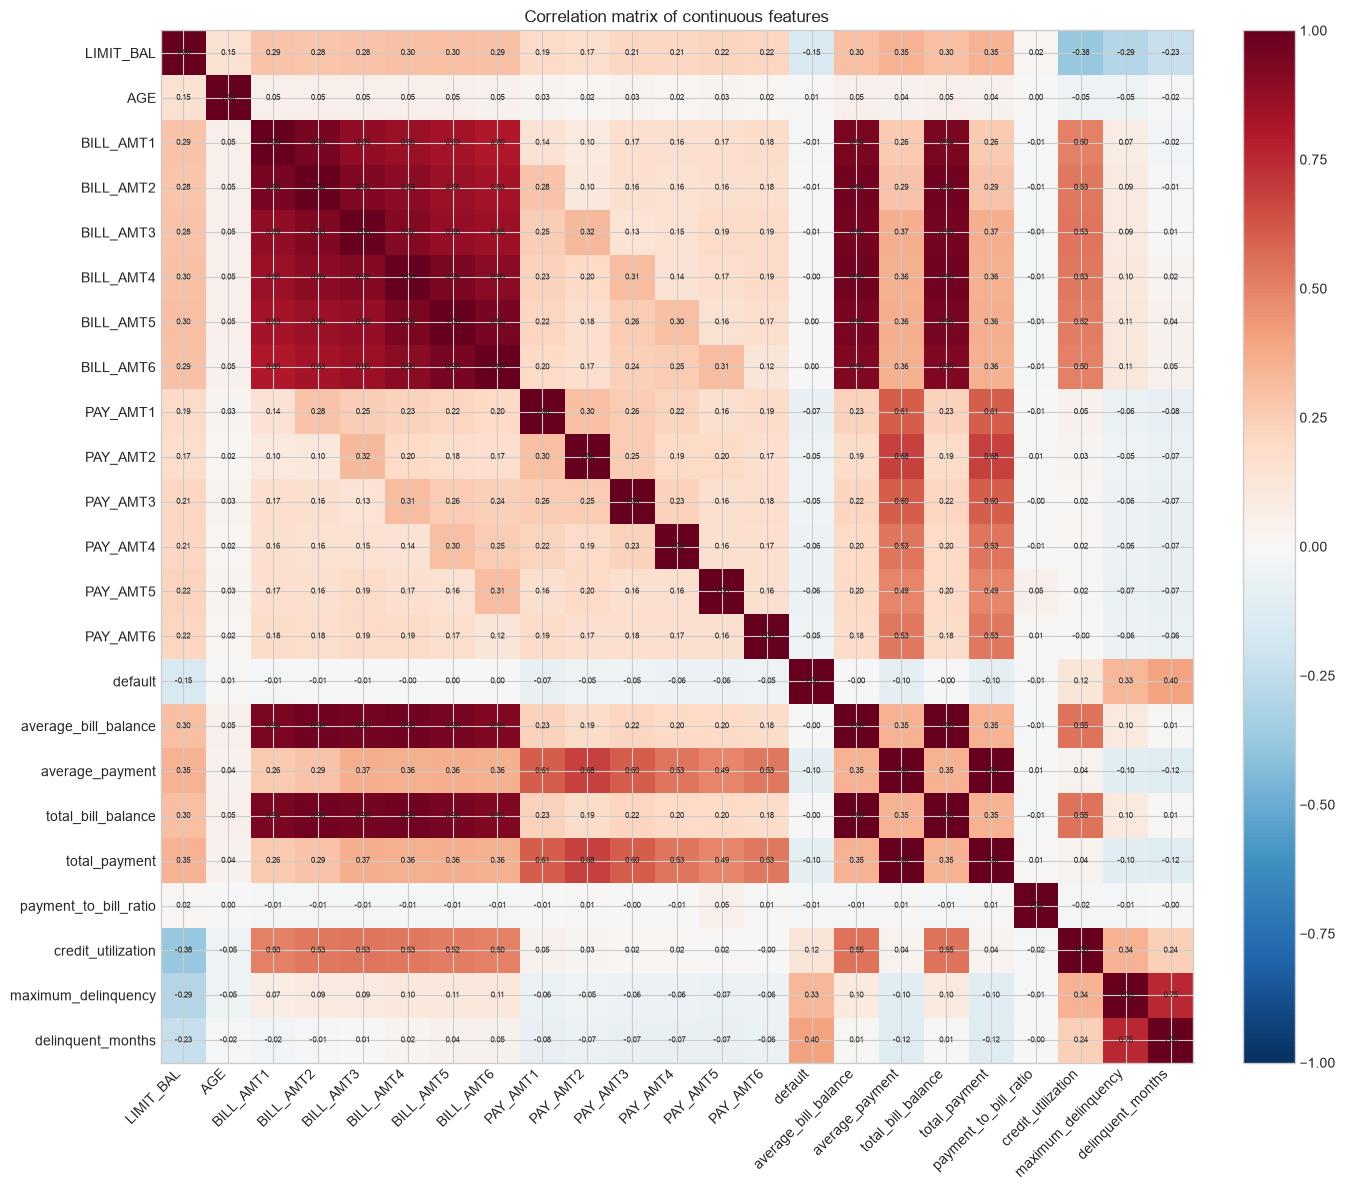

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,...,PAY_AMT6,default,average_bill_balance,average_payment,total_bill_balance,total_payment,payment_to_bill_ratio,credit_utilization,maximum_delinquency,delinquent_months
LIMIT_BAL,1.00,0.15,0.29,0.28,0.28,0.30,0.30,0.29,0.19,0.17,...,0.22,-0.15,0.30,0.35,0.30,0.35,0.02,-0.38,-0.29,-0.23
AGE,0.15,1.00,0.05,0.05,0.05,0.05,0.05,0.05,0.03,0.02,...,0.02,0.01,0.05,0.04,0.05,0.04,0.00,-0.05,-0.05,-0.02
BILL_AMT1,0.29,0.05,1.00,0.95,0.89,0.86,0.83,0.80,0.14,0.10,...,0.18,-0.01,0.94,0.26,0.94,0.26,-0.01,0.50,0.07,-0.02
BILL_AMT2,0.28,0.05,0.95,1.00,0.93,0.89,0.86,0.83,0.28,0.10,...,0.18,-0.01,0.96,0.29,0.96,0.29,-0.01,0.53,0.09,-0.01
BILL_AMT3,0.28,0.05,0.89,0.93,1.00,0.92,0.88,0.85,0.25,0.32,...,0.19,-0.01,0.96,0.37,0.96,0.37,-0.01,0.53,0.09,0.01
BILL_AMT4,0.30,0.05,0.86,0.89,0.92,1.00,0.94,0.90,0.23,0.20,...,0.19,-0.00,0.96,0.36,0.96,0.36,-0.01,0.53,0.10,0.02
BILL_AMT5,0.30,0.05,0.83,0.86,0.88,0.94,1.00,0.95,0.22,0.18,...,0.17,0.00,0.95,0.36,0.95,0.36,-0.01,0.52,0.11,0.04
BILL_AMT6,0.29,0.05,0.80,0.83,0.85,0.90,0.95,1.00,0.20,0.17,...,0.12,0.00,0.93,0.36,0.93,0.36,-0.01,0.50,0.11,0.05
PAY_AMT1,0.19,0.03,0.14,0.28,0.25,0.23,0.22,0.20,1.00,0.30,...,0.19,-0.07,0.23,0.61,0.23,0.61,-0.01,0.05,-0.06,-0.08
PAY_AMT2,0.17,0.02,0.10,0.10,0.32,0.20,0.18,0.17,0.30,1.00,...,0.17,-0.05,0.19,0.68,0.19,0.68,0.01,0.03,-0.05,-0.07


In [28]:
continuous_features = [
    column for column in train.columns
    if column not in {
        'client_id', 'SEX', 'EDUCATION', 'MARRIAGE',
        'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    }
]
correlation_matrix = train[continuous_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
image = ax.imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(continuous_features)), continuous_features, rotation=45, ha='right')
ax.set_yticks(range(len(continuous_features)), continuous_features)
ax.set_title('Correlation matrix of continuous features')
for row in range(len(continuous_features)):
    for col in range(len(continuous_features)):
        ax.text(col, row, f'{correlation_matrix.iloc[row, col]:.2f}', ha='center', va='center', fontsize=6)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()
correlation_matrix.round(2)

For each continuous feature, a one-predictor logistic regression is fit on the training data. A two-sided Wald test then evaluates \(H_0: \beta = 0\) against \(H_1: \beta \neq 0\).

In [29]:
univariate_rows = []
for feature in continuous_features:
    if feature == 'default':
        continue
    design = sm.add_constant(train[[feature]])
    model = sm.Logit(train['default'], design).fit(disp=False)
    p_value = model.pvalues[feature]
    univariate_rows.append({
        'feature': feature,
        'coefficient': model.params[feature],
        'std_error': model.bse[feature],
        'z_statistic': model.tvalues[feature],
        'p_value': p_value,
        'reject_h0_0.05': p_value < 0.05,
    })

univariate_tests = pd.DataFrame(univariate_rows).sort_values('p_value').reset_index(drop=True)
print(f'Reject H0 at 5% for {univariate_tests["reject_h0_0.05"].sum()} of {len(univariate_tests)} features')
univariate_tests.round({'coefficient': 6, 'std_error': 6, 'z_statistic': 3})

Reject H0 at 5% for 12 of 22 features


,feature,coefficient,std_error,z_statistic,p_value,reject_h0_0.05
0,delinquent_months,0.529221,0.010011,52.865,0.000000e+00,True
1,maximum_delinquency,0.619969,0.013189,47.007,0.000000e+00,True
2,LIMIT_BAL,-0.000003,0.000000,-22.960,1.177806e-116,True
3,credit_utilization,0.815702,0.043454,18.772,1.290912e-78,True
4,average_payment,-0.000057,0.000003,-17.000,8.144682e-65,True
5,total_payment,-0.000010,0.000001,-17.000,8.144682e-65,True
6,PAY_AMT1,-0.000035,0.000003,-12.400,2.604871e-35,True
7,PAY_AMT2,-0.000028,0.000003,-11.130,8.999459e-29,True
8,PAY_AMT4,-0.000021,0.000002,-9.190,3.944394e-20,True
9,PAY_AMT5,-0.000019,0.000002,-8.585,9.119147e-18,True


Cramér's V measures association between each categorical feature and the others. Values range from 0 (no association) to 1 (perfect association).

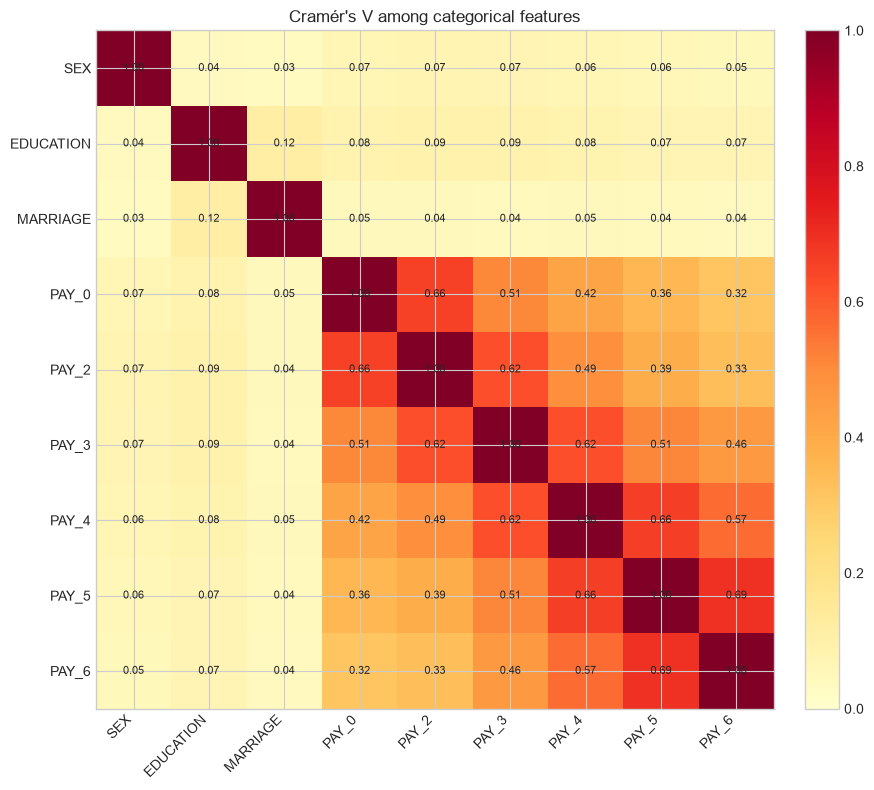

,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
SEX,1.00,0.04,0.03,0.07,0.07,0.07,0.06,0.06,0.05
EDUCATION,0.04,1.00,0.12,0.08,0.09,0.09,0.08,0.07,0.07
MARRIAGE,0.03,0.12,1.00,0.05,0.04,0.04,0.05,0.04,0.04
PAY_0,0.07,0.08,0.05,1.00,0.66,0.51,0.42,0.36,0.32
PAY_2,0.07,0.09,0.04,0.66,1.00,0.62,0.49,0.39,0.33
PAY_3,0.07,0.09,0.04,0.51,0.62,1.00,0.62,0.51,0.46
PAY_4,0.06,0.08,0.05,0.42,0.49,0.62,1.00,0.66,0.57
PAY_5,0.06,0.07,0.04,0.36,0.39,0.51,0.66,1.00,0.69
PAY_6,0.05,0.07,0.04,0.32,0.33,0.46,0.57,0.69,1.00


In [30]:
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE'] + [f'PAY_{period}' for period in [0, 2, 3, 4, 5, 6]]

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    degrees = min(table.shape) - 1
    if n == 0 or degrees <= 0:
        return np.nan
    return float(np.sqrt(chi2 / (n * degrees)))

cramers_matrix = pd.DataFrame(index=categorical_features, columns=categorical_features, dtype=float)
for row_feature in categorical_features:
    for col_feature in categorical_features:
        if row_feature == col_feature:
            cramers_matrix.loc[row_feature, col_feature] = 1.0
        else:
            cramers_matrix.loc[row_feature, col_feature] = cramers_v(train[row_feature], train[col_feature])

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(cramers_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(categorical_features)), categorical_features, rotation=45, ha='right')
ax.set_yticks(range(len(categorical_features)), categorical_features)
ax.set_title("Cramér's V among categorical features")
for row in range(len(categorical_features)):
    for col in range(len(categorical_features)):
        ax.text(col, row, f'{cramers_matrix.iloc[row, col]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()
cramers_matrix.round(2)

A chi-square test of independence is run for each categorical feature against `default`. The null hypothesis is that the feature and default are independent; the alternative is that they are associated.

In [31]:
chi_square_rows = []
for feature in categorical_features:
    table = pd.crosstab(train[feature], train['default'])
    chi2, p_value, degrees_of_freedom, _ = chi2_contingency(table)
    chi_square_rows.append({
        'feature': feature,
        'chi2': chi2,
        'degrees_of_freedom': degrees_of_freedom,
        'p_value': p_value,
        'reject_h0_0.05': p_value < 0.05,
    })

chi_square_tests = pd.DataFrame(chi_square_rows).sort_values('p_value').reset_index(drop=True)
print(f'Reject H0 at 5% for {chi_square_tests["reject_h0_0.05"].sum()} of {len(chi_square_tests)} features')
chi_square_tests.round({'chi2': 3})

Reject H0 at 5% for 9 of 9 features


,feature,chi2,degrees_of_freedom,p_value,reject_h0_0.05
0,PAY_0,4298.057,10,0.000000e+00,True
1,PAY_2,2785.817,10,0.000000e+00,True
2,PAY_3,2180.865,10,0.000000e+00,True
3,PAY_4,1875.716,10,0.000000e+00,True
4,PAY_5,1771.938,9,0.000000e+00,True
5,PAY_6,1540.095,9,0.000000e+00,True
6,EDUCATION,124.415,6,1.924342e-24,True
7,SEX,31.055,1,2.508533e-08,True
8,MARRIAGE,24.903,3,1.618060e-05,True


Significant features are kept only if they reject \(H_0\). Among remaining continuous features, if \(|r| > 0.5\), only the feature with the largest absolute Wald statistic is kept. Among remaining categorical features, if Cramér's V \(> 0.5\), only the feature with the largest chi-square statistic is kept.

In [32]:
CORRELATION_THRESHOLD = 0.2
CRAMERS_THRESHOLD = 0.5

def select_representatives(tests, association, statistic, threshold, use_absolute_statistic=False):
    significant = tests.loc[tests['reject_h0_0.05']].copy()
    ranks = significant[statistic].abs() if use_absolute_statistic else significant[statistic]
    significant = significant.assign(_rank=ranks).sort_values('_rank', ascending=False)
    selected = []
    decisions = []
    for row in significant.itertuples(index=False):
        feature = row.feature
        blockers = [kept for kept in selected if association.loc[feature, kept] > threshold]
        keep = len(blockers) == 0
        if keep:
            selected.append(feature)
        decisions.append({
            'feature': feature,
            'test_statistic': getattr(row, statistic),
            'kept': keep,
            'dropped_for': blockers[0] if blockers else '',
        })
    return selected, pd.DataFrame(decisions)

continuous_association = correlation_matrix.drop(index='default', errors='ignore').drop(columns='default', errors='ignore').abs()
selected_continuous, continuous_selection = select_representatives(
    univariate_tests, continuous_association, 'z_statistic', CORRELATION_THRESHOLD, use_absolute_statistic=True,
)
selected_categorical, categorical_selection = select_representatives(
    chi_square_tests, cramers_matrix, 'chi2', CRAMERS_THRESHOLD,
)
selected_features = selected_continuous + selected_categorical

print('Continuous selection')
print(continuous_selection.round({'test_statistic': 3}).to_string(index=False))
print('\nCategorical selection')
print(categorical_selection.round({'test_statistic': 3}).to_string(index=False))
print('\nSelected features:')
print(selected_features)

Continuous selection
            feature  test_statistic  kept       dropped_for
  delinquent_months          52.865  True                  
maximum_delinquency          47.007 False delinquent_months
          LIMIT_BAL         -22.960 False delinquent_months
 credit_utilization          18.772 False delinquent_months
    average_payment         -17.000  True                  
      total_payment         -17.000 False   average_payment
           PAY_AMT1         -12.400 False   average_payment
           PAY_AMT2         -11.130 False   average_payment
           PAY_AMT4          -9.190 False   average_payment
           PAY_AMT5          -8.585 False   average_payment
           PAY_AMT3          -8.234 False   average_payment
           PAY_AMT6          -8.083 False   average_payment

Categorical selection
  feature  test_statistic  kept dropped_for
    PAY_0        4298.057  True            
    PAY_2        2785.817 False       PAY_0
    PAY_3        2180.865 False       PAY_0


## 3. Prepare features and validation data

Only the selected features enter the models. Categorical codes are one-hot encoded, while numeric features are standardized inside the scikit-learn pipeline. The split is stratified so the validation default rate matches the training distribution.

In [33]:
target = 'default'
id_column = 'client_id'
categorical_columns = selected_categorical
feature_columns = selected_features
x = train[feature_columns]
y = train[target]
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

def make_pipeline(model):
    categorical = [column for column in categorical_columns if column in feature_columns]
    numeric = [column for column in feature_columns if column not in categorical]
    transformer = ColumnTransformer([
        ('numeric', StandardScaler(), numeric),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
    ])
    return Pipeline([('preprocess', transformer), ('model', model)])

## 4. Compare regression models

The linear probability model directly answers the requested linear-regression use case. Logistic regression is included as a classification comparison. For probability prediction, ROC-AUC, log loss, Brier score, and mean absolute error are more informative than accuracy alone.

In [34]:
N_LHS_SAMPLES = 12
lhs_draws = LatinHypercube(d=5, seed=42).random(n=N_LHS_SAMPLES)
activations = ['relu', 'tanh']
lhs_rows = []

for sample_id, draw in enumerate(lhs_draws, start=1):
    hidden_size = int(round(2 ** (3 + draw[0] * 4)))
    n_layers = 1 + int(draw[1] < 0.5)
    hidden_layer_sizes = tuple([hidden_size] * n_layers)
    alpha = 10 ** (-5 + draw[2] * 4)
    learning_rate_init = 10 ** (-4 + draw[3] * 3)
    activation = activations[int(draw[4] < 0.5)]
    candidate = make_pipeline(MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        activation=activation,
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
    ))
    preprocess = candidate.named_steps['preprocess']
    preprocess.set_params(categorical__sparse_output=False)
    candidate.fit(x_train, y_train)
    probabilities = candidate.predict_proba(x_valid)[:, 1]
    lhs_rows.append({
        'sample': sample_id,
        'hidden_layer_sizes': hidden_layer_sizes,
        'alpha': alpha,
        'learning_rate_init': learning_rate_init,
        'activation': activation,
        'roc_auc': roc_auc_score(y_valid, probabilities),
        'log_loss': log_loss(y_valid, probabilities, labels=[0, 1]),
        'accuracy': accuracy_score(y_valid, (probabilities >= 0.5).astype(int)),
        'model': candidate,
    })

lhs_results = pd.DataFrame(lhs_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
best_lhs = lhs_results.iloc[0]
neural_net_model = best_lhs['model']
print(f'Best LHS sample {int(best_lhs["sample"])}: hidden={best_lhs["hidden_layer_sizes"]}, activation={best_lhs["activation"]}')
print(f'  alpha={best_lhs["alpha"]:.4g}, learning_rate_init={best_lhs["learning_rate_init"]:.4g}')
print(f'  ROC-AUC={best_lhs["roc_auc"]:.4f}, log loss={best_lhs["log_loss"]:.4f}, accuracy={best_lhs["accuracy"]:.4f}')
lhs_results.drop(columns='model').round({'alpha': 6, 'learning_rate_init': 6, 'roc_auc': 4, 'log_loss': 4, 'accuracy': 4})

Best LHS sample 12: hidden=(34,), activation=relu
  alpha=0.0006463, learning_rate_init=0.009227
  ROC-AUC=0.7634, log loss=0.4428, accuracy=0.8094


,sample,hidden_layer_sizes,alpha,learning_rate_init,activation,roc_auc,log_loss,accuracy
0,12,"(34,)",0.000646,0.009227,relu,0.7634,0.4428,0.8094
1,1,"(11, 11)",0.005174,0.003764,relu,0.7611,0.4442,0.8085
2,5,"(68, 68)",0.010227,0.010635,relu,0.7599,0.4457,0.8096
3,6,"(31,)",0.002083,0.001627,tanh,0.7572,0.4453,0.8094
4,10,"(17,)",0.000173,0.000380,tanh,0.7568,0.4469,0.8115
5,7,"(54, 54)",0.036146,0.002555,relu,0.7563,0.4484,0.8104
6,3,"(117, 117)",0.000028,0.000623,relu,0.7559,0.4458,0.8098
7,9,"(14,)",0.002712,0.000149,tanh,0.7546,0.4481,0.8150
8,4,"(24, 24)",0.000021,0.034921,tanh,0.7538,0.4473,0.8098
9,2,"(8,)",0.000055,0.000294,tanh,0.7536,0.4474,0.8110


In [35]:
def evaluate_model(name, model):
    model.fit(x_train, y_train)
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(x_valid)[:, 1]
    else:
        probabilities = np.clip(model.predict(x_valid), 0, 1)
    predictions = (probabilities >= 0.5).astype(int)
    print(name)
    print(f'  ROC-AUC:           {roc_auc_score(y_valid, probabilities):.4f}')
    print(f'  Average precision: {average_precision_score(y_valid, probabilities):.4f}')
    print(f'  Log loss:          {log_loss(y_valid, probabilities, labels=[0, 1]):.4f}')
    print(f'  Brier score:       {brier_score_loss(y_valid, probabilities):.4f}')
    print(f'  Accuracy:          {accuracy_score(y_valid, predictions):.4f}')
    print(f'  Mean absolute error: {mean_absolute_error(y_valid, probabilities):.4f}')
    return model

linear_model = evaluate_model('Linear probability regression', make_pipeline(LinearRegression()))
logistic_model = evaluate_model('Logistic regression comparison', make_pipeline(LogisticRegression(max_iter=2000)))
neural_net_model = evaluate_model('Neural network (LHS-tuned)', make_pipeline(MLPClassifier(
    hidden_layer_sizes=(11, 11),
    alpha=0.005173693460665387,
    learning_rate_init=0.003764072612068487,
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
)))


Linear probability regression
  ROC-AUC:           0.7479
  Average precision: 0.5123
  Log loss:          0.4654
  Brier score:       0.1421
  Accuracy:          0.8094
  Mean absolute error: 0.2771
Logistic regression comparison
  ROC-AUC:           0.7512
  Average precision: 0.5135
  Log loss:          0.4509
  Brier score:       0.1418
  Accuracy:          0.8102
  Mean absolute error: 0.2763
Neural network (LHS-tuned)
  ROC-AUC:           0.7611
  Average precision: 0.5220
  Log loss:          0.4442
  Brier score:       0.1400
  Accuracy:          0.8085
  Mean absolute error: 0.2796


Latin hypercube sampling spreads candidate settings across the hyperparameter space. Each draw is used to train a multilayer perceptron on the selected features; the configuration with the highest validation ROC-AUC is kept.

## 5. Fit the selected model and create the submission

The linear model is selected based on the supplied holdout results. Predictions are clipped to `[0, 1]` so they are valid default probabilities.

In [36]:
linear_model.fit(x, y)
test_probabilities = np.clip(linear_model.predict(test[feature_columns]), 0, 1)
submission = pd.DataFrame({
    'client_id': test['client_id'],
    'default_probability': test_probabilities,
})
submission.to_csv('submission.csv', index=False)
print(f'Wrote {len(submission):,} predictions to submission.csv')
print(f'Probability range: {submission.default_probability.min():.4f} to {submission.default_probability.max():.4f}')
submission.head()

Wrote 6,000 predictions to submission.csv
Probability range: 0.0000 to 0.8889


,client_id,default_probability
0,CC_0012A082B7B7,0.232593
1,CC_0012BC27DFB6,0.146389
2,CC_001563B2143D,0.157692
3,CC_001B46930B6F,0.096401
4,CC_001D771E1C9F,0.113354
